# B̄0 → K*0 τ+ τ- (τ_μ τ_h) — generator-level plots

Reads the CSV written by `gen/gen_bkstautau` and plots true-level quantities:
B0 flight distance, K and π pT/η, the hadronic-τ visible "jet" pT/η, the muon pT/η,
and the anti-kT R=0.4 gen-jets of the signal B and of the opposite-side b-hadron,
with and without neutrinos.

Kernel: `Python 3.12 (bkstautau)` = `~/bkstautau/env` (micromamba; numpy, pandas, matplotlib).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

CSV = "../gen/bkstautau.csv"
df = pd.read_csv(CSV)
print(f"{len(df)} signal candidates from {df.event.nunique()} events")
df.head()

15105 signal candidates from 15105 events


,event,Bid,B_osc,B_fd,B_px,B_py,B_pz,B_e,Kst_px,Kst_py,...,taumu_dec_x,taumu_dec_y,taumu_dec_z,tauh_fd,tauh_dec_x,tauh_dec_y,tauh_dec_z,mech,mech_stat,oth_mech
0,6,-511,0,2.908000,-30.74060,-19.4960,-0.906714,36.7937,-5.15219,-2.55580,...,-2.595440,-1.643350,-0.073767,0.160600,-2.583490,-1.652540,-0.084777,1,23,1
1,7,-511,0,1.579510,-12.28680,-25.9506,5.729180,29.7505,-2.07572,-3.78371,...,-0.940131,-1.973180,0.509840,1.430110,-1.243050,-2.682990,0.559014,1,23,1
2,14,-511,0,6.211480,8.61088,49.7607,92.290000,105.3360,1.42975,6.98337,...,0.566455,3.276980,6.115140,4.831100,0.902012,5.304780,9.642260,1,23,1
3,15,-511,0,8.929680,85.66850,68.1819,384.364000,399.6890,27.66680,22.60080,...,2.507200,2.002760,11.234600,1.754870,2.292530,1.807020,10.278000,1,23,1
4,21,-511,0,0.921993,17.11520,13.7903,-16.310900,27.8751,8.02983,6.23572,...,0.631256,0.520764,-0.607244,0.132099,0.662156,0.524133,-0.630481,1,23,1


In [2]:
def pt(p):
    return np.hypot(df[f"{p}_px"], df[f"{p}_py"])

def eta(p):
    pz = df[f"{p}_pz"]
    return np.arcsinh(pz / pt(p))

for p in ["B", "K", "pi", "mu", "tauh", "oth", "sigjet", "sigjetnonu", "othjet", "othjetnonu"]:
    df[f"{p}_pt"] = pt(p)
    df[f"{p}_eta"] = eta(p)

# B0 flight distance is in mm (Pythia vertex units); q2 in GeV^2
df[["B_fd", "B_pt", "K_pt", "pi_pt", "mu_pt", "tauh_pt", "q2"]].describe().T

/tmp/ipykernel_3408339/3608188905.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_eta"] = eta(p)
/tmp/ipykernel_3408339/3608188905.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_pt"] = pt(p)


,count,mean,std,min,25%,50%,75%,max
B_fd,15105.0,19.895468,38.982778,0.000953,3.024270,8.510080,20.708800,1196.580000
B_pt,15105.0,89.293170,41.566662,0.105707,67.150350,88.699248,109.112126,465.604530
K_pt,15105.0,13.148272,9.748033,0.030412,6.384345,10.987368,17.400344,106.209087
pi_pt,15105.0,7.585382,6.801177,0.036721,2.657878,5.762222,10.463997,69.109079
mu_pt,15105.0,12.154899,11.181488,0.026404,3.826371,9.120731,17.199921,137.192359
tauh_pt,15105.0,22.121489,15.420185,0.020780,11.119796,19.624575,29.862000,190.947059
q2,15105.0,15.739788,1.646660,12.631800,14.407000,15.670700,17.021500,20.559400


## Sample composition

In [3]:
print("B flavour at production:", df.Bid.value_counts().to_dict())
print("oscillated fraction      :", f"{df.B_osc.mean():.3f}")
print("muonic tau charge        :", df.mu_id.map({13: 'mu-  (tau-)', -13: 'mu+  (tau+)'}).value_counts().to_dict())
print("hadronic tau prongs      :", df.tauh_nprong.value_counts().sort_index().to_dict())

B flavour at production: {-511: 12956, 511: 2149}
oscillated fraction      : 0.142
muonic tau charge        : {'mu+  (tau+)': 7649, 'mu-  (tau-)': 7456}
hadronic tau prongs      : {1: 11274, 3: 3788, 5: 43}


## B0 flight distance

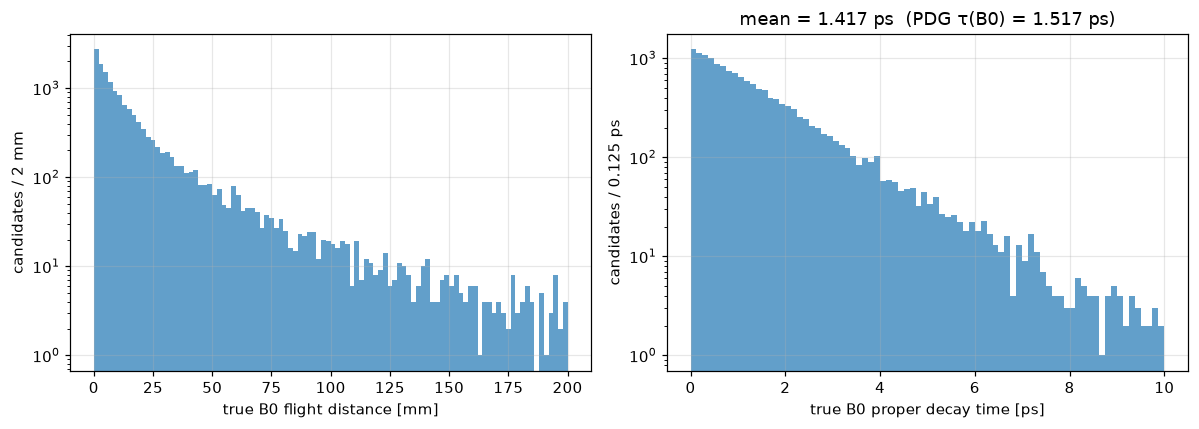

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df.B_fd, bins=100, range=(0, 200), histtype="stepfilled", alpha=0.7)
ax[0].set_xlabel("true B0 flight distance [mm]")
ax[0].set_ylabel("candidates / 2 mm")
ax[0].set_yscale("log")

# proper decay time t = L m / p  ->  should be exponential with tau_B0 ~ 1.52 ps
c_mm_per_ps = 0.299792458
p = np.sqrt(df.B_px**2 + df.B_py**2 + df.B_pz**2)
m = np.sqrt(np.clip(df.B_e**2 - p**2, 0, None))
t_ps = df.B_fd * m / p / c_mm_per_ps
ax[1].hist(t_ps, bins=80, range=(0, 10), histtype="stepfilled", alpha=0.7)
ax[1].set_xlabel("true B0 proper decay time [ps]")
ax[1].set_ylabel("candidates / 0.125 ps")
ax[1].set_yscale("log")
ax[1].set_title(f"mean = {t_ps.mean():.3f} ps  (PDG τ(B0) = 1.517 ps)")
fig.tight_layout()

### Proper time split by oscillation

The sample is selected on the flavour **at decay** (anti-B0), so the proper-time
distribution is *not* a plain exponential per production flavour:
`P(unmixed) ∝ e^{-t/τ}(1 + cos Δm t)/2` (biased short) and
`P(mixed) ∝ e^{-t/τ}(1 − cos Δm t)/2` (biased long). Summed over a 50/50 B0/anti-B0
production the bias cancels, but the veto on events with *two* signal decays removes
mixed signal B's preferentially (their recoil b-hadron is a wrong-sign B that is
anti-B0 at decay ~80 % of the time, vs ~20 % for the unmixed case), which pulls the
overall mean below τ. Curves: analytic shapes with Pythia's τ(B0) = 0.4587 mm/c and
x_d = 0.776, normalised to the histograms.

mixed fraction in sample 0.142  vs chi_d = 0.188 without the two-signal veto
sample mean 1.417 ps; expected from the two components with the observed mixed fraction: 1.423 ps; with chi_d: 1.530 ps (= τ = 1.530 ps)


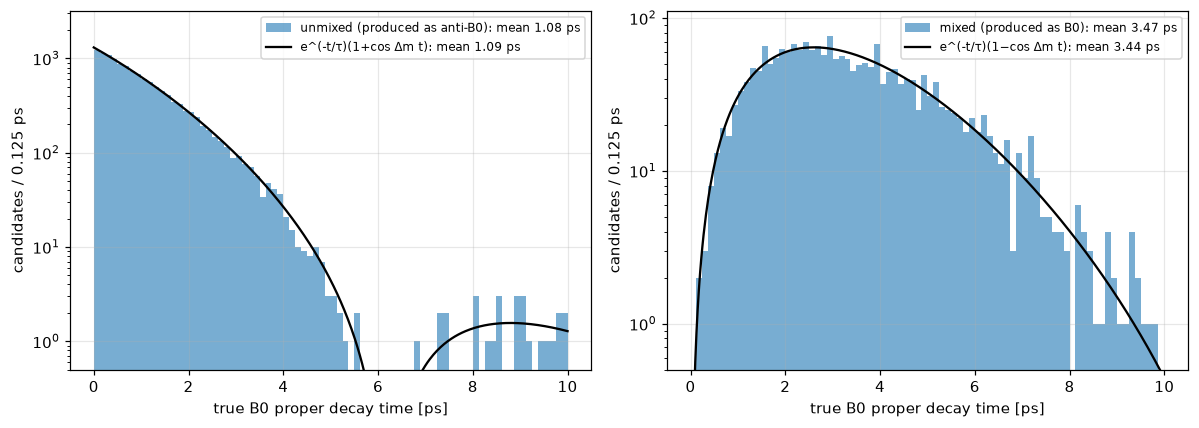

In [5]:
tau_B = 0.4587 / c_mm_per_ps          # Pythia 511:tau0 -> ps
x_d = 0.776                            # Pythia ParticleDecays:xBdMix
dm = x_d / tau_B                       # ps^-1

def mean_t(sign):
    # mean of e^{-t/tau}(1 + sign cos(dm t))/2
    num = tau_B**2 + sign * tau_B**2 * (1 - x_d**2) / (1 + x_d**2)**2
    den = tau_B + sign * tau_B / (1 + x_d**2)
    return num / den

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tt = np.linspace(0, 10, 400)
bins = np.linspace(0, 10, 81)
for a, (sign, sel, lab) in zip(ax, [(+1, df.B_osc == 0, "unmixed (produced as anti-B0)"),
                                    (-1, df.B_osc == 1, "mixed (produced as B0)")]):
    t = t_ps[sel]
    a.hist(t, bins=bins, histtype="stepfilled", alpha=0.6, label=f"{lab}: mean {t.mean():.2f} ps")
    f = np.exp(-tt / tau_B) * (1 + sign * np.cos(dm * tt)) / 2
    f *= len(t) * (bins[1] - bins[0]) / np.trapezoid(f, tt)
    a.plot(tt, f, "k-", lw=1.5, label=f"e^(-t/τ)(1{'+' if sign > 0 else '−'}cos Δm t): mean {mean_t(sign):.2f} ps")
    a.set_xlabel("true B0 proper decay time [ps]")
    a.set_ylabel("candidates / 0.125 ps")
    a.set_yscale("log"); a.set_ylim(bottom=0.5)
    a.legend(fontsize=8)
fig.tight_layout()

f_mix = df.B_osc.mean()
f_mix_exp = (1 - 1 / (1 + x_d**2)) / 2            # chi_d, no double-signal veto
print(f"mixed fraction in sample {f_mix:.3f}  vs chi_d = {f_mix_exp:.3f} without the two-signal veto")
print(f"sample mean {t_ps.mean():.3f} ps; expected from the two components with the observed mixed fraction: "
      f"{(1 - f_mix) * mean_t(+1) + f_mix * mean_t(-1):.3f} ps; with chi_d: "
      f"{(1 - f_mix_exp) * mean_t(+1) + f_mix_exp * mean_t(-1):.3f} ps (= τ = {tau_B:.3f} ps)")

## Final-state kinematics: pT and η

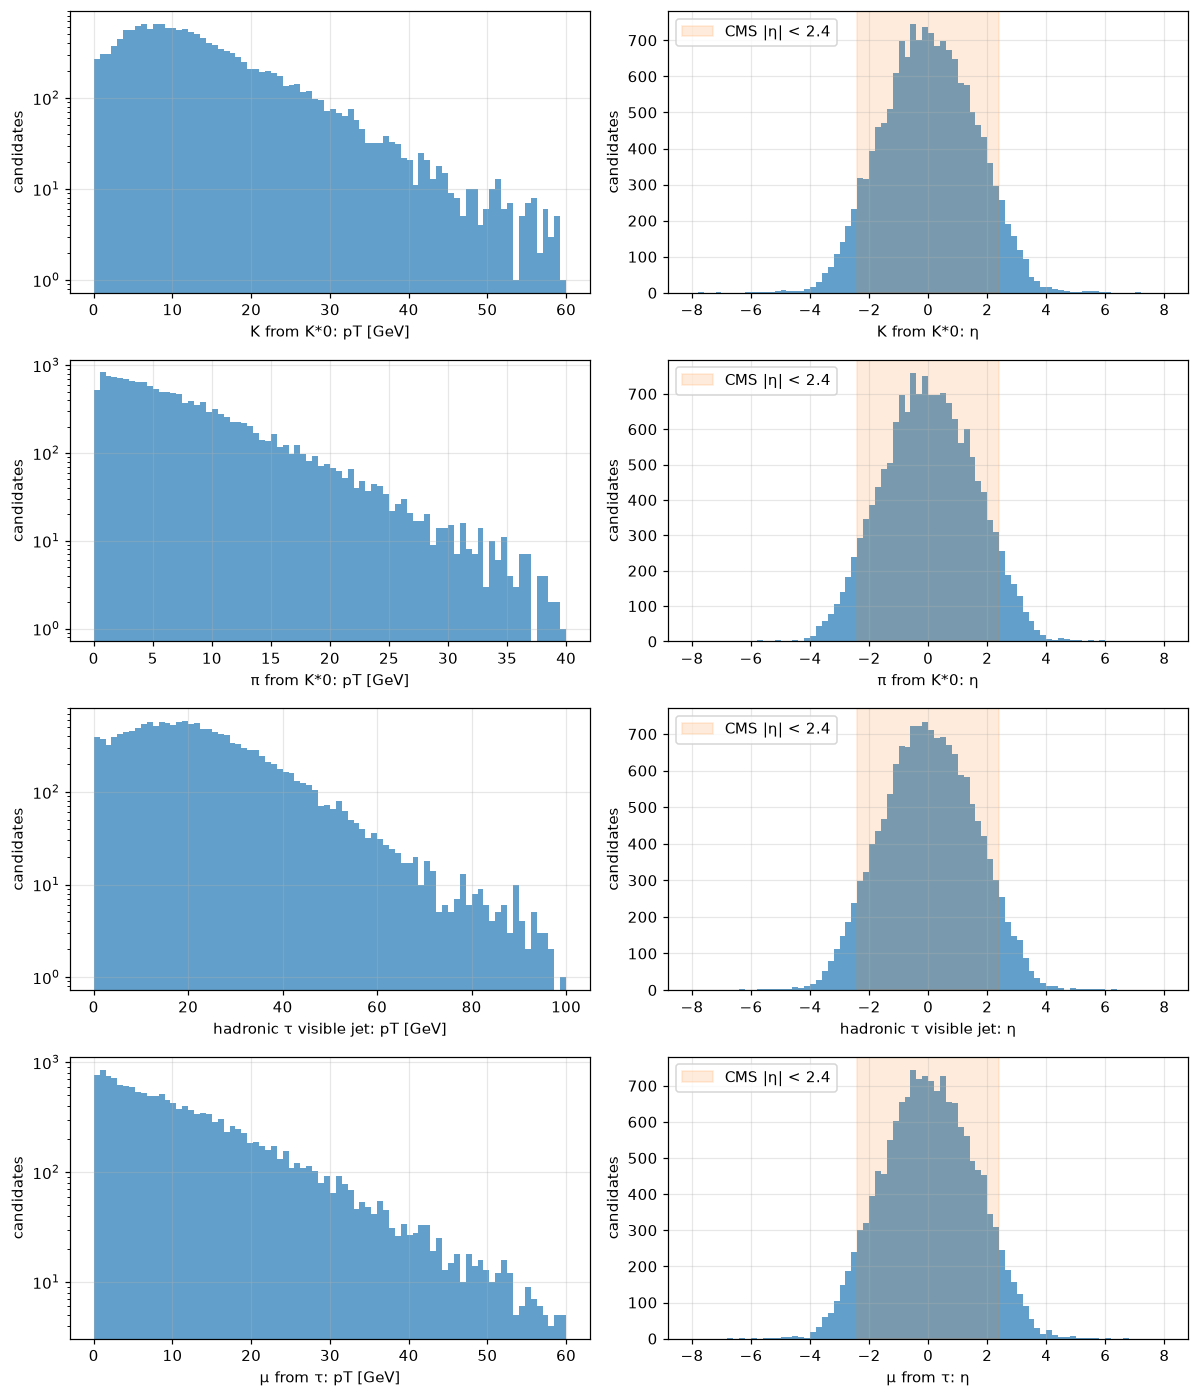

In [6]:
particles = [
    ("K",    "K from K*0",            (0, 60)),
    ("pi",   "π from K*0",            (0, 40)),
    ("tauh", "hadronic τ visible jet", (0, 100)),
    ("mu",   "μ from τ",              (0, 60)),
]

fig, axes = plt.subplots(len(particles), 2, figsize=(11, 3.2 * len(particles)))
for (p, label, pt_range), (axl, axr) in zip(particles, axes):
    axl.hist(df[f"{p}_pt"], bins=80, range=pt_range, histtype="stepfilled", alpha=0.7)
    axl.set_xlabel(f"{label}: pT [GeV]")
    axl.set_ylabel("candidates")
    axl.set_yscale("log")

    axr.hist(df[f"{p}_eta"], bins=80, range=(-8, 8), histtype="stepfilled", alpha=0.7)
    axr.axvspan(-2.4, 2.4, color="tab:orange", alpha=0.15, label="CMS |η| < 2.4")
    axr.set_xlabel(f"{label}: η")
    axr.set_ylabel("candidates")
    axr.legend(loc="upper left")
fig.tight_layout()

## Everything in the CMS acceptance

Fraction of candidates with K, π, μ and the visible hadronic-τ system all within |η| < 2.4 (tracker / muon-system coverage), and the same distributions for that subset.

all four visible objects in |η| < 2.4: 12978 / 15105 = 0.859


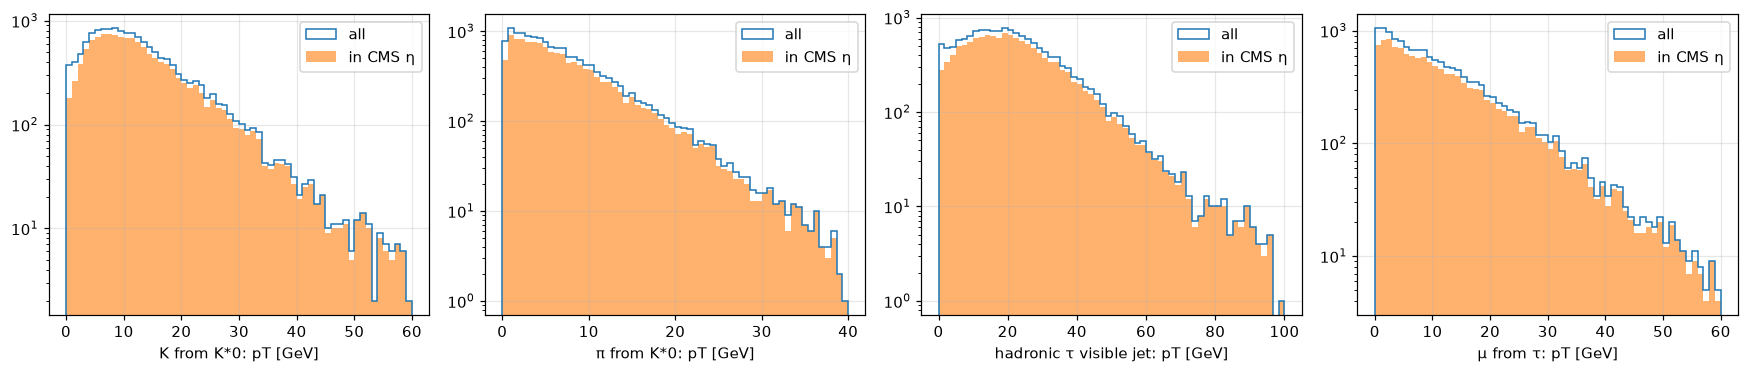

In [7]:
in_acc = np.ones(len(df), dtype=bool)
for p in ["K", "pi", "mu", "tauh"]:
    in_acc &= np.abs(df[f"{p}_eta"]) < 2.4
print(f"all four visible objects in |η| < 2.4: {in_acc.sum()} / {len(df)} = {in_acc.mean():.3f}")

sel = df[in_acc]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (p, label, pt_range) in zip(axes, particles):
    ax.hist(df[f"{p}_pt"],  bins=60, range=pt_range, histtype="step", label="all")
    ax.hist(sel[f"{p}_pt"], bins=60, range=pt_range, histtype="stepfilled", alpha=0.6, label="in CMS η")
    ax.set_xlabel(f"{label}: pT [GeV]")
    ax.set_yscale("log")
    ax.legend()
fig.tight_layout()

## Impact parameters w.r.t. the primary vertex

Straight-line (no B field) impact parameters of the true particle trajectories w.r.t.
the primary vertex `pv` (production vertex of the signal B; the origin in this sample).
The K and π originate at the B decay vertex (`Bdec`), the muon at the decay vertex of
the muonic τ (`taumu_dec`), i.e. after the B flight *plus* the τ flight.

* `dxy`: transverse distance of closest approach, CMS sign convention
  `dxy = (−x·py + y·px)/pT`; `|dxy|` is what matters for displacement.
* `dxy_ls`: lifetime-signed `|dxy|`: positive if the transverse point of closest approach lies
  along the B flight direction (the b-tagging IP sign, with the true B direction instead of the jet axis).
* `dz`: longitudinal distance at the transverse point of closest approach.
* `ip3d`: 3D distance of closest approach `|r × p̂|`.

Units: mm (Pythia vertex units), 1 mm = 1000 µm.

In [8]:
def impact_pars(p, vtx, ref="pv"):
    # r = production vertex of p relative to ref vertex, p = true momentum
    rx = df[f"{vtx}_x"] - df[f"{ref}_x"]
    ry = df[f"{vtx}_y"] - df[f"{ref}_y"]
    rz = df[f"{vtx}_z"] - df[f"{ref}_z"]
    px, py, pz = df[f"{p}_px"], df[f"{p}_py"], df[f"{p}_pz"]
    pt_ = np.hypot(px, py)
    pabs = np.sqrt(px**2 + py**2 + pz**2)
    dxy = (-rx * py + ry * px) / pt_
    s = (rx * px + ry * py) / pt_                       # path length to transverse PCA
    dz = rz - s * pz / pt_
    # 3D distance of closest approach
    cx = ry * pz - rz * py; cy = rz * px - rx * pz; cz = rx * py - ry * px
    ip3d = np.sqrt(cx**2 + cy**2 + cz**2) / pabs
    # lifetime sign: transverse PCA point dotted with the B transverse direction
    pcax = rx - s * px / pt_; pcay = ry - s * py / pt_
    sign = np.sign(pcax * df.B_px + pcay * df.B_py)
    return dxy, sign * np.abs(dxy), dz, ip3d

objs = [("mu", "taumu_dec", "μ (from τ)"), ("K", "Bdec", "K (from K*)"), ("pi", "Bdec", "π (from K*)")]
for p, vtx, _ in objs:
    df[f"{p}_dxy"], df[f"{p}_dxy_ls"], df[f"{p}_dz"], df[f"{p}_ip3d"] = impact_pars(p, vtx)
# muon w.r.t. the B decay vertex: the tau-flight-only contribution
df["mu_dxy_Bv"], _, df["mu_dz_Bv"], df["mu_ip3d_Bv"] = impact_pars("mu", "taumu_dec", ref="Bdec")

rows = []
for p, _, lab in objs:
    for sel_name, sel in [("all", np.ones(len(df), bool)), ("in acc.", in_acc)]:
        d = df[sel]
        rows.append(dict(object=lab, sel=sel_name,
                         **{"|dxy| median [mm]": np.abs(d[f"{p}_dxy"]).median(),
                            "|dxy| mean [mm]": np.abs(d[f"{p}_dxy"]).mean(),
                            "|dz| median [mm]": np.abs(d[f"{p}_dz"]).median(),
                            "ip3d median [mm]": d[f"{p}_ip3d"].median(),
                            "f(dxy_ls>0)": (d[f"{p}_dxy_ls"] > 0).mean()}))
pd.DataFrame(rows).round(4)

/tmp/ipykernel_3408339/660062689.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_dxy"], df[f"{p}_dxy_ls"], df[f"{p}_dz"], df[f"{p}_ip3d"] = impact_pars(p, vtx)
/tmp/ipykernel_3408339/660062689.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mu_dxy_Bv"], _, df["mu_dz_Bv"], df["mu_ip3d_Bv"] = impact_pars("mu", "taumu_dec", ref="Bdec")


,object,sel,|dxy| median [mm],|dxy| mean [mm],|dz| median [mm],ip3d median [mm],f(dxy_ls>0)
0,μ (from τ),all,0.1931,0.4223,0.3832,0.3545,0.9648
1,μ (from τ),in acc.,0.1953,0.4235,0.3137,0.3548,0.9649
2,K (from K*),all,0.0876,0.1842,0.1733,0.1656,1.0000
3,K (from K*),in acc.,0.0876,0.1848,0.1437,0.1658,1.0000
4,π (from K*),all,0.1220,0.2871,0.2463,0.2309,1.0000
5,π (from K*),in acc.,0.1223,0.2883,0.2022,0.2293,1.0000


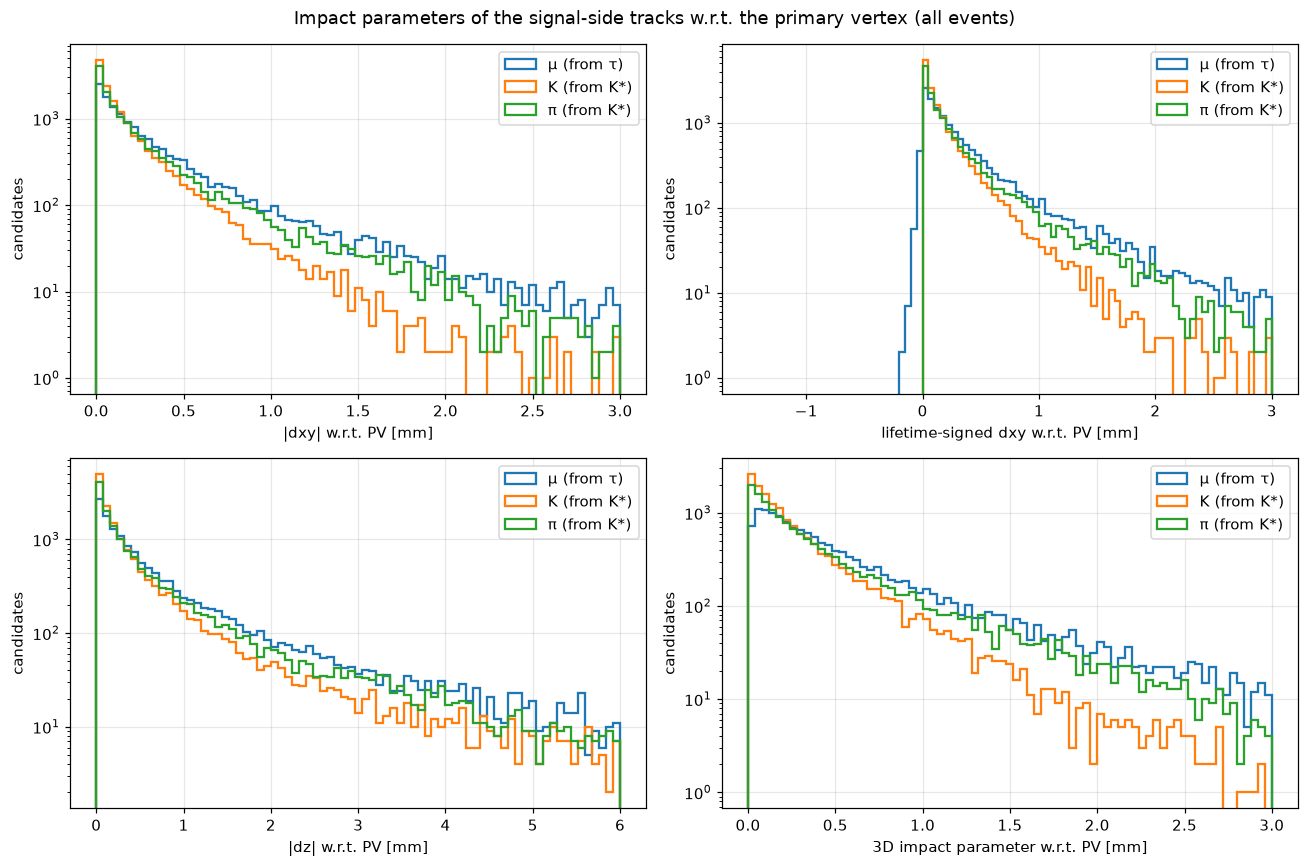

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
bins_xy = np.linspace(0, 3, 76)
for p, _, lab in objs:
    ax[0, 0].hist(np.abs(df[f"{p}_dxy"]), bins=bins_xy, histtype="step", lw=1.5, label=lab)
    ax[0, 1].hist(df[f"{p}_dxy_ls"], bins=np.linspace(-1.5, 3, 91), histtype="step", lw=1.5, label=lab)
    ax[1, 0].hist(np.abs(df[f"{p}_dz"]), bins=np.linspace(0, 6, 76), histtype="step", lw=1.5, label=lab)
    ax[1, 1].hist(df[f"{p}_ip3d"], bins=bins_xy, histtype="step", lw=1.5, label=lab)
ax[0, 0].set_xlabel("|dxy| w.r.t. PV [mm]")
ax[0, 1].set_xlabel("lifetime-signed dxy w.r.t. PV [mm]")
ax[1, 0].set_xlabel("|dz| w.r.t. PV [mm]")
ax[1, 1].set_xlabel("3D impact parameter w.r.t. PV [mm]")
for a in ax.flat:
    a.set_yscale("log"); a.set_ylabel("candidates"); a.legend()
fig.suptitle("Impact parameters of the signal-side tracks w.r.t. the primary vertex (all events)")
fig.tight_layout()

muons in acceptance (12978), and with pT > 3 GeV (10568):
  |dxy| >   20 µm   50 µm  100 µm  200 µm  500 µm  1 mm
  in acc.         0.914   0.802   0.674   0.493   0.240   0.101
  in acc., pT>3   0.902   0.777   0.638   0.444   0.183   0.062
same for the kaon (in acc., pT>3):
                    0.792   0.631   0.462   0.278   0.088   0.021


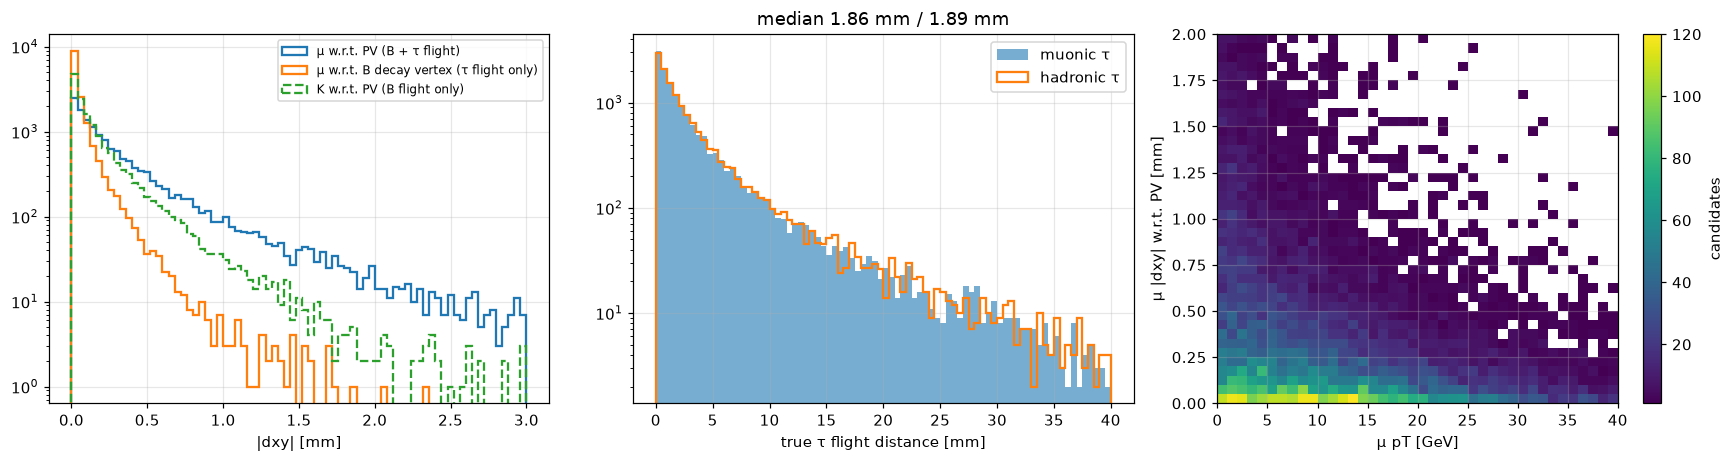

In [10]:
# Muon: where does the displacement come from?  B flight vs tau flight.
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].hist(np.abs(df.mu_dxy), bins=bins_xy, histtype="step", lw=1.5, label="μ w.r.t. PV (B + τ flight)")
ax[0].hist(np.abs(df.mu_dxy_Bv), bins=bins_xy, histtype="step", lw=1.5, label="μ w.r.t. B decay vertex (τ flight only)")
ax[0].hist(np.abs(df.K_dxy), bins=bins_xy, histtype="step", lw=1.5, ls="--", label="K w.r.t. PV (B flight only)")
ax[0].set_xlabel("|dxy| [mm]"); ax[0].set_yscale("log"); ax[0].legend(fontsize=8)

ax[1].hist(df.taumu_fd, bins=np.linspace(0, 40, 81), histtype="stepfilled", alpha=0.6, label="muonic τ")
ax[1].hist(df.tauh_fd, bins=np.linspace(0, 40, 81), histtype="step", lw=1.5, label="hadronic τ")
ax[1].set_xlabel("true τ flight distance [mm]"); ax[1].set_yscale("log"); ax[1].legend()
ax[1].set_title(f"median {df.taumu_fd.median():.2f} mm / {df.tauh_fd.median():.2f} mm")

h = ax[2].hist2d(df.mu_pt, np.abs(df.mu_dxy), bins=[np.linspace(0, 40, 41), np.linspace(0, 2, 41)], cmin=1)
ax[2].set_xlabel("μ pT [GeV]"); ax[2].set_ylabel("μ |dxy| w.r.t. PV [mm]")
fig.colorbar(h[3], ax=ax[2], label="candidates")
fig.tight_layout()

# fractions of muons above displacement thresholds, in acceptance
sel = in_acc
print(f"muons in acceptance ({sel.sum()}), and with pT > 3 GeV ({(sel & (df.mu_pt > 3)).sum()}):")
print("  |dxy| >   20 µm   50 µm  100 µm  200 µm  500 µm  1 mm")
for lab_, s in [("in acc.        ", sel), ("in acc., pT>3  ", sel & (df.mu_pt > 3))]:
    fr = [(np.abs(df.mu_dxy[s]) > c).mean() for c in (0.02, 0.05, 0.1, 0.2, 0.5, 1.0)]
    print("  " + lab_ + "  ".join(f"{f:6.3f}" for f in fr))
print("same for the kaon (in acc., pT>3):")
s = sel & (df.K_pt > 3)
print("                   " + "  ".join(f"{(np.abs(df.K_dxy[s]) > c).mean():6.3f}" for c in (0.02, 0.05, 0.1, 0.2, 0.5, 1.0)))

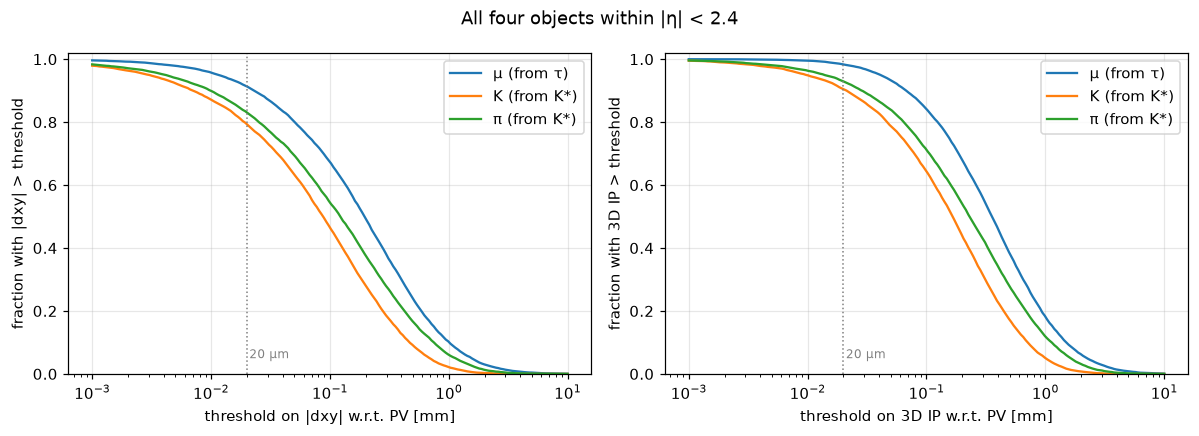

In [11]:
# Cumulative view: fraction of candidates with |IP| above a threshold (in acceptance)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
thr = np.logspace(-3, 1, 200)   # 1 µm .. 10 mm
for p, _, lab in objs:
    v = np.abs(df[f"{p}_dxy"][in_acc]).values
    ax[0].plot(thr, [(v > c).mean() for c in thr], lw=1.5, label=lab)
    v = df[f"{p}_ip3d"][in_acc].values
    ax[1].plot(thr, [(v > c).mean() for c in thr], lw=1.5, label=lab)
for a, t in zip(ax, ["|dxy|", "3D IP"]):
    a.set_xscale("log"); a.set_xlabel(f"threshold on {t} w.r.t. PV [mm]")
    a.set_ylabel(f"fraction with {t} > threshold"); a.set_ylim(0, 1.02); a.legend()
    a.axvline(0.02, color="gray", ls=":", lw=1); a.text(0.021, 0.05, "20 µm", fontsize=8, color="gray")
fig.suptitle("All four objects within |η| < 2.4")
fig.tight_layout()

## Gen-jets of the two b-hadrons

Anti-kT R = 0.4 (FastJet) on all final-state particles, clustered twice: **with** neutrinos and **without** (CMS `ak4GenJets`-like, pT > 3 GeV).
Each b-hadron is ghost-associated to its jet. `sigjet*` is the jet containing the signal B̄0, `othjet*` the jet containing the
highest-pT other weakly-decaying b-hadron (`oth_id`).

In [12]:
def phi(p):
    return np.arctan2(df[f"{p}_py"], df[f"{p}_px"])

def dR(a, b):
    dphi = (phi(a) - phi(b) + np.pi) % (2 * np.pi) - np.pi
    return np.hypot(df[f"{a}_eta"] - df[f"{b}_eta"], dphi)

has_sig = df.sigjet_px.notna()
has_oth = df.othjet_px.notna()
names = {511: "B0", -511: "B̄0", 521: "B+", -521: "B-", 531: "Bs", -531: "B̄s", 5122: "Λb", -5122: "Λ̄b"}
print("other b-hadron        :", df.oth_id.map(lambda i: names.get(i, str(i))).value_counts().to_dict())
print("extra b-hadrons/event :", df.n_oth_bhad.value_counts().sort_index().to_dict(), "(1 = just the opposite-side b)")
print(f"signal B in a jet     : {has_sig.mean():.3f}   other b in a jet: {has_oth.mean():.3f}   both in the same jet: {df.jets_shared.mean():.4f}")
print(f"jets/event (pT>3 GeV) : {df.njets.mean():.1f} with ν, {df.njets_nonu.mean():.1f} without")
print(f"ΔR(B̄0, sigjet) median : {dR('sigjet','B')[has_sig].median():.3f}   ΔR(other b, othjet) median: {dR('othjet','oth')[has_oth].median():.3f}")

other b-hadron        : {'B+': 5896, 'B0': 4836, 'B-': 1596, 'Bs': 1293, 'Λ̄b': 496, 'B̄s': 370, 'B̄0': 279, 'Λb': 150, '-5132': 82, '-5232': 66, '5132': 25, '5232': 12, '-5332': 3, '5332': 1}
extra b-hadrons/event : {1: 13749, 3: 1296, 5: 59, 7: 1} (1 = just the opposite-side b)
signal B in a jet     : 0.987   other b in a jet: 0.999   both in the same jet: 0.0009
jets/event (pT>3 GeV) : 18.6 with ν, 18.5 without
ΔR(B̄0, sigjet) median : 0.014   ΔR(other b, othjet) median: 0.013


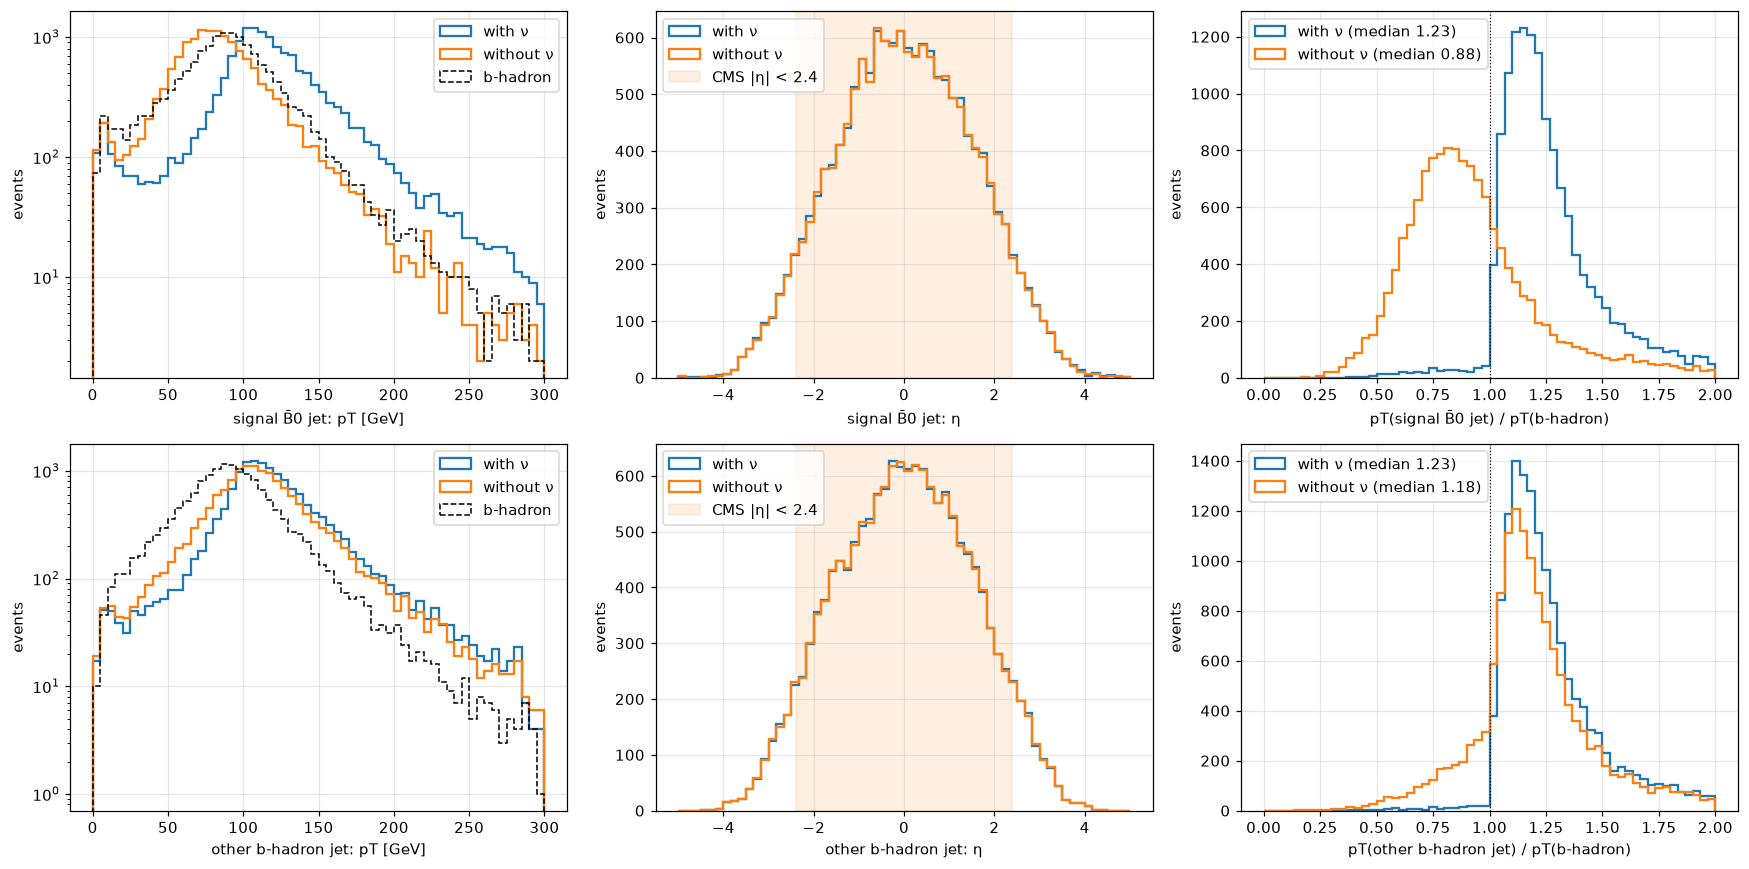

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (tag, had, label) in enumerate([("sigjet", "B", "signal B̄0 jet"), ("othjet", "oth", "other b-hadron jet")]):
    ok = df[f"{tag}_px"].notna()
    ax = axes[row, 0]
    ax.hist(df[f"{tag}_pt"][ok],       bins=60, range=(0, 300), histtype="step", lw=1.5, label="with ν")
    ax.hist(df[f"{tag}nonu_pt"][ok],   bins=60, range=(0, 300), histtype="step", lw=1.5, label="without ν")
    ax.hist(df[f"{had}_pt"][ok],       bins=60, range=(0, 300), histtype="step", lw=1.0, ls="--", color="k", label="b-hadron")
    ax.set_xlabel(f"{label}: pT [GeV]"); ax.set_ylabel("events"); ax.set_yscale("log"); ax.legend()

    ax = axes[row, 1]
    ax.hist(df[f"{tag}_eta"][ok],     bins=60, range=(-5, 5), histtype="step", lw=1.5, label="with ν")
    ax.hist(df[f"{tag}nonu_eta"][ok], bins=60, range=(-5, 5), histtype="step", lw=1.5, label="without ν")
    ax.axvspan(-2.4, 2.4, color="tab:orange", alpha=0.12, label="CMS |η| < 2.4")
    ax.set_xlabel(f"{label}: η"); ax.set_ylabel("events"); ax.legend(loc="upper left")

    ax = axes[row, 2]
    resp_nu   = (df[f"{tag}_pt"] / df[f"{had}_pt"])[ok]
    resp_nonu = (df[f"{tag}nonu_pt"] / df[f"{had}_pt"])[ok]
    ax.hist(resp_nu,   bins=60, range=(0, 2), histtype="step", lw=1.5, label=f"with ν (median {resp_nu.median():.2f})")
    ax.hist(resp_nonu, bins=60, range=(0, 2), histtype="step", lw=1.5, label=f"without ν (median {resp_nonu.median():.2f})")
    ax.axvline(1, color="k", lw=0.8, ls=":")
    ax.set_xlabel(f"pT({label}) / pT(b-hadron)"); ax.set_ylabel("events"); ax.legend()
fig.tight_layout()

### Neutrino energy fraction

For the signal jet the two τ decays plus the muonic τ's two neutrinos carry away a lot of the B̄0 momentum, so
`pT(no ν) / pT(with ν)` is well below 1. The opposite-side b-jet only loses neutrinos in semileptonic b/c decays (~20 % of the time).

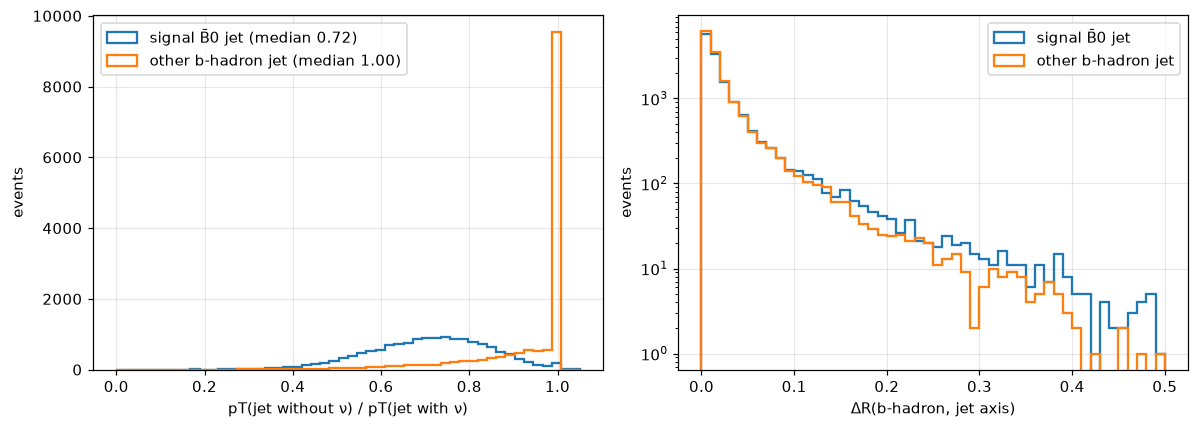

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for tag, label in [("sigjet", "signal B̄0 jet"), ("othjet", "other b-hadron jet")]:
    ok = df[f"{tag}_px"].notna() & df[f"{tag}nonu_px"].notna()
    f = (df[f"{tag}nonu_pt"] / df[f"{tag}_pt"])[ok]
    ax[0].hist(f, bins=50, range=(0, 1.05), histtype="step", lw=1.5, label=f"{label} (median {f.median():.2f})")
    ax[1].hist(dR(tag, "B" if tag == "sigjet" else "oth")[ok], bins=50, range=(0, 0.5), histtype="step", lw=1.5, label=label)
ax[0].set_xlabel("pT(jet without ν) / pT(jet with ν)"); ax[0].set_ylabel("events"); ax[0].legend(loc="upper left")
ax[1].set_xlabel("ΔR(b-hadron, jet axis)"); ax[1].set_ylabel("events"); ax[1].set_yscale("log"); ax[1].legend()
fig.tight_layout()

## Transverse balance of the two b-jets

Events where both b-hadrons have a jet (and not the same one). `pT(signal jet) / pT(other jet)`, the asymmetry
`A = (pT_sig − pT_oth)/(pT_sig + pT_oth)`, and |Δφ| between the two jets, with and without neutrinos, plus the mixed case (signal jet with ν, recoil jet without). The signal jet loses
the four τ neutrinos, so without neutrinos it is systematically softer than the recoil jet; adding the signal-chain MET back
recovers the balance (dashed). The b-hadron-level ratio is shown for reference.

/tmp/ipykernel_3408339/4149423530.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_phi"] = phi(p)


events with two distinct b-jets: 14780 / 15105
pT(sig)/pT(oth) with ν                : 16/50/84 % = 0.72 / 0.99 / 1.35
pT(sig)/pT(oth) without ν             : 16/50/84 % = 0.48 / 0.74 / 1.11
pT(sig)/pT(oth) sig with ν, other without: 16/50/84 % = 0.75 / 1.05 / 1.51
pT(sig)/pT(oth) without ν + MET_sig   : 16/50/84 % = 0.75 / 1.05 / 1.51
pT(sig)/pT(oth) b-hadrons             : 16/50/84 % = 0.58 / 0.98 / 1.59


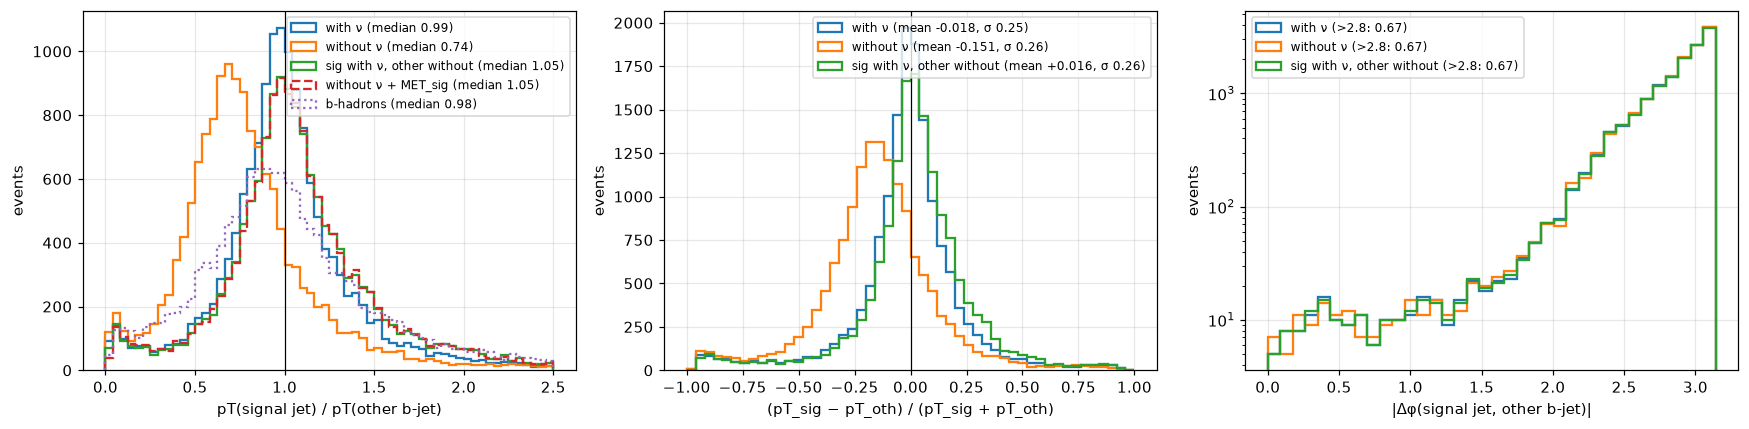

In [15]:
for p in ["sigjet", "sigjetnonu", "othjet", "othjetnonu", "B", "oth"]:
    df[f"{p}_phi"] = phi(p)
both = df.sigjet_px.notna() & df.othjet_px.notna() & df.sigjetnonu_px.notna() & df.othjetnonu_px.notna() & (df.jets_shared == 0)
d = df[both]
print(f"events with two distinct b-jets: {both.sum()} / {len(df)}")

def q16_50_84(x):
    return " / ".join(f"{v:.2f}" for v in np.quantile(x, [0.16, 0.5, 0.84]))

ratios = {
    "with ν":           d.sigjet_pt / d.othjet_pt,
    "without ν":        d.sigjetnonu_pt / d.othjetnonu_pt,
    "sig with ν, other without": d.sigjet_pt / d.othjetnonu_pt,
    "without ν + MET_sig": np.hypot(d.sigjetnonu_px + d.metsig_px, d.sigjetnonu_py + d.metsig_py) / d.othjetnonu_pt,
    "b-hadrons":        d.B_pt / d.oth_pt,
}
for k, r in ratios.items():
    print(f"pT(sig)/pT(oth) {k:22s}: 16/50/84 % = {q16_50_84(r)}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for (k, r), ls in zip(ratios.items(), ["-", "-", "-", "--", ":"]):
    ax[0].hist(r, bins=60, range=(0, 2.5), histtype="step", lw=1.5, ls=ls, label=f"{k} (median {r.median():.2f})")
ax[0].axvline(1, color="k", lw=0.8)
ax[0].set_xlabel("pT(signal jet) / pT(other b-jet)"); ax[0].set_ylabel("events"); ax[0].legend(fontsize=8)

for s, o, label in [("sigjet", "othjet", "with ν"), ("sigjetnonu", "othjetnonu", "without ν"), ("sigjet", "othjetnonu", "sig with ν, other without")]:
    A = (d[f"{s}_pt"] - d[f"{o}_pt"]) / (d[f"{s}_pt"] + d[f"{o}_pt"])
    ax[1].hist(A, bins=50, range=(-1, 1), histtype="step", lw=1.5, label=f"{label} (mean {A.mean():+.3f}, σ {A.std():.2f})")
    dphi_jj = np.abs((d[f"{s}_phi"] - d[f"{o}_phi"] + np.pi) % (2 * np.pi) - np.pi)
    ax[2].hist(dphi_jj, bins=36, range=(0, np.pi), histtype="step", lw=1.5, label=f"{label} (>2.8: {(dphi_jj > 2.8).mean():.2f})")
ax[1].axvline(0, color="k", lw=0.8)
ax[1].set_xlabel("(pT_sig − pT_oth) / (pT_sig + pT_oth)"); ax[1].set_ylabel("events"); ax[1].legend(fontsize=8)
ax[2].set_xlabel("|Δφ(signal jet, other b-jet)|"); ax[2].set_ylabel("events"); ax[2].set_yscale("log"); ax[2].legend(loc="upper left", fontsize=8)
fig.tight_layout()

## Inclusive QCD sample: b production mechanism and b-jet topology

The hard-scatter `bb̄` sample above contains only the leading-order *pair-creation*
mechanism (gg → bb̄, qq̄ → bb̄), which is a minority of b production at the LHC.
`gen/bkstautau_incl.csv` is an inclusive hard-QCD sample (`HardQCD:all`,
p̂T > 10 GeV, 20 seeds × 40k events, σ ≈ 8 mb) with the same forced signal decay;
b quarks then come from all mechanisms in their natural proportions. The CSV column `mech`
classifies the signal B from the ancestry of its b quark (Pythia status of the earliest b):

| `mech` | mechanism | earliest b |
|---|---|---|
| 1 | pair creation (PC) | outgoing from the hardest 2→2 (status 23), no incoming b |
| 2 | flavour excitation (FE) | incoming to the hardest 2→2 (21), ISR incoming b (41, 42) or ISR companion of a backward g → bb̄ (43, 44) |
| 3 | gluon splitting (GS) | made in the final-state shower (51) |
| 4 | MPI | in a secondary 2→2 (31, 33) |

`oth_mech` is the same for the recoil b-hadron. Caveat: ISR companions of an MPI
incoming b are counted as FE (status codes do not distinguish the ISR of the hard and MPI systems).
Note the inclusive sample is much softer (p̂T > 10 vs 100 GeV): compare topologies, not absolute pT.

In [16]:
di = pd.read_csv("../gen/bkstautau_incl100.csv")
print(f"inclusive sample: {len(di)} signal candidates")

MECH = {1: "pair creation", 2: "flavour excitation", 3: "gluon splitting", 4: "MPI", 5: "other"}

def kin(d, p):
    pt_ = np.hypot(d[f"{p}_px"], d[f"{p}_py"])
    return pt_, np.arcsinh(d[f"{p}_pz"] / pt_), np.arctan2(d[f"{p}_py"], d[f"{p}_px"])

def derive(d):
    for p in ["B", "oth", "K", "pi", "mu", "tauh", "sigjet", "sigjetnonu", "othjet", "othjetnonu"]:
        d[f"{p}_pt"], d[f"{p}_eta"], d[f"{p}_phi"] = kin(d, p)
    dphi = (d.B_phi - d.oth_phi + np.pi) % (2 * np.pi) - np.pi
    d["dphi_Both"] = np.abs(dphi)
    d["dR_Both"] = np.hypot(d.B_eta - d.oth_eta, dphi)
    d["in_acc"] = np.ones(len(d), bool)
    for p in ["K", "pi", "mu", "tauh"]:
        d["in_acc"] &= np.abs(d[f"{p}_eta"]) < 2.4
    return d

derive(di)
derive(df)   # adds dphi_Both, dR_Both, in_acc (already defined) to the hard sample

rows = []
for name, d in [("hard bb̄, p̂T>100", df), ("inclusive, p̂T>10", di)]:
    for m in [1, 2, 3, 4]:
        s = d.mech == m
        if s.sum() == 0: continue
        rows.append(dict(sample=name, mechanism=MECH[m], fraction=s.mean(), n=int(s.sum()),
                         **{"B pT med [GeV]": d.B_pt[s].median(),
                            "oth pT med [GeV]": d.oth_pt[s].median(),
                            "dR(B,oth) med": d.dR_Both[s].median(),
                            "|dphi| med": d.dphi_Both[s].median(),
                            "f(dR<0.4)": (d.dR_Both[s] < 0.4).mean(),
                            "f(same jet)": d.jets_shared[s].mean(),
                            "f(oth |eta|<2.4)": (np.abs(d.oth_eta[s]) < 2.4).mean(),
                            "f(oth jet)": d.othjet_pt[s].notna().mean(),
                            "f(sig in acc)": d.in_acc[s].mean()}))
    rows.append(dict(sample=name, mechanism="all", fraction=1.0, n=len(d),
                     **{"B pT med [GeV]": d.B_pt.median(), "oth pT med [GeV]": d.oth_pt.median(),
                        "dR(B,oth) med": d.dR_Both.median(), "|dphi| med": d.dphi_Both.median(),
                        "f(dR<0.4)": (d.dR_Both < 0.4).mean(), "f(same jet)": d.jets_shared.mean(),
                        "f(oth |eta|<2.4)": (np.abs(d.oth_eta) < 2.4).mean(),
                        "f(oth jet)": d.othjet_pt.notna().mean(), "f(sig in acc)": d.in_acc.mean()}))
pd.DataFrame(rows).round(3)

inclusive sample: 10896 signal candidates


/tmp/ipykernel_3408339/1381397418.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d[f"{p}_pt"], d[f"{p}_eta"], d[f"{p}_phi"] = kin(d, p)
/tmp/ipykernel_3408339/1381397418.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["dphi_Both"] = np.abs(dphi)
/tmp/ipykernel_3408339/1381397418.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

,sample,mechanism,fraction,n,B pT med [GeV],oth pT med [GeV],"dR(B,oth) med",|dphi| med,f(dR<0.4),f(same jet),f(oth |eta|<2.4),f(oth jet),f(sig in acc)
0,"hard bb̄, p̂T>100",pair creation,0.952,14386,90.463,90.313,3.130,2.934,0.000,0.000,0.886,0.999,0.876
1,"hard bb̄, p̂T>100",flavour excitation,0.012,175,6.613,106.267,3.537,1.799,0.006,0.006,0.897,1.000,0.417
2,"hard bb̄, p̂T>100",gluon splitting,0.029,442,9.396,104.602,3.043,2.047,0.018,0.020,0.862,1.000,0.586
3,"hard bb̄, p̂T>100",MPI,0.006,94,6.027,103.066,2.966,1.600,0.000,0.000,0.926,1.000,0.511
4,"hard bb̄, p̂T>100",all,1.000,15105,88.699,91.027,3.129,2.923,0.001,0.001,0.886,0.999,0.859
5,"inclusive, p̂T>10",pair creation,0.024,262,88.177,88.057,3.155,2.922,0.000,0.000,0.885,1.000,0.844
6,"inclusive, p̂T>10",flavour excitation,0.292,3181,16.811,21.554,2.797,1.749,0.009,0.012,0.640,0.870,0.553
7,"inclusive, p̂T>10",gluon splitting,0.613,6675,17.442,18.858,1.008,0.618,0.228,0.244,0.744,0.889,0.690
8,"inclusive, p̂T>10",MPI,0.066,721,6.159,4.611,2.821,2.235,0.007,0.010,0.520,0.577,0.473
9,"inclusive, p̂T>10",all,1.000,10896,15.787,18.080,1.765,1.080,0.143,0.153,0.700,0.863,0.637


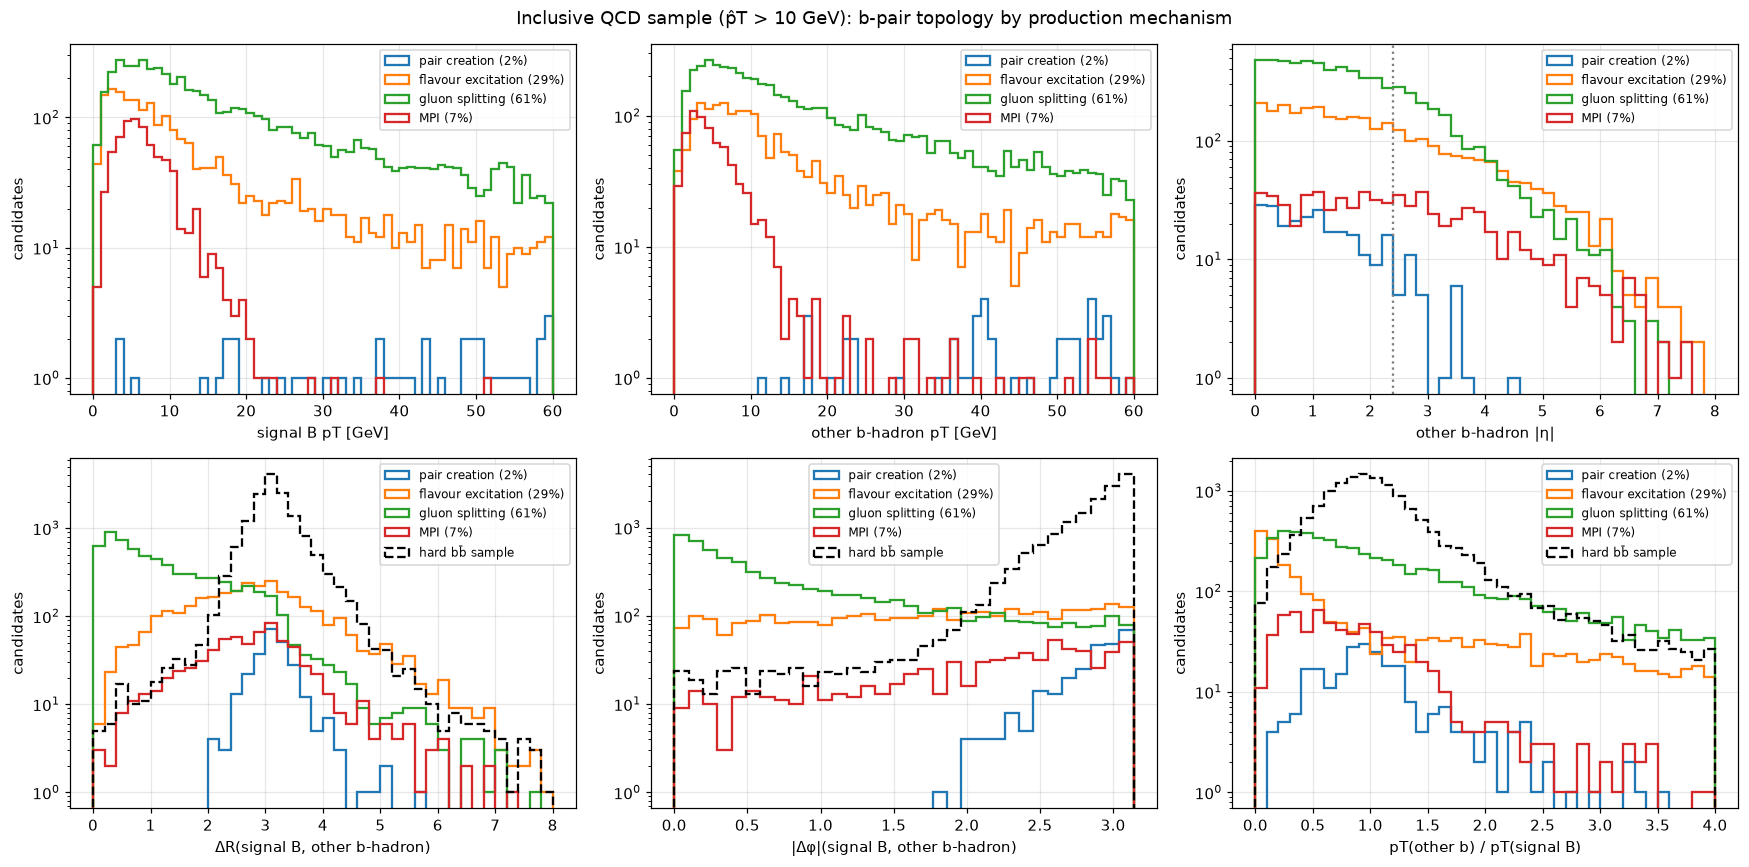

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
cols = {1: "C0", 2: "C1", 3: "C2", 4: "C3"}
for m in [1, 2, 3, 4]:
    s = di.mech == m
    kw = dict(histtype="step", lw=1.5, color=cols[m], label=f"{MECH[m]} ({s.mean():.0%})")
    ax[0, 0].hist(di.B_pt[s], bins=np.linspace(0, 60, 61), **kw)
    ax[0, 1].hist(di.oth_pt[s], bins=np.linspace(0, 60, 61), **kw)
    ax[0, 2].hist(np.abs(di.oth_eta[s]), bins=np.linspace(0, 8, 41), **kw)
    ax[1, 0].hist(di.dR_Both[s], bins=np.linspace(0, 8, 41), **kw)
    ax[1, 1].hist(di.dphi_Both[s], bins=np.linspace(0, np.pi, 33), **kw)
    ax[1, 2].hist(di.oth_pt[s] / di.B_pt[s], bins=np.linspace(0, 4, 41), **kw)
ax[1, 0].hist(df.dR_Both, bins=np.linspace(0, 8, 41), histtype="step", lw=1.5, color="k", ls="--", label="hard bb̄ sample")
ax[1, 1].hist(df.dphi_Both, bins=np.linspace(0, np.pi, 33), histtype="step", lw=1.5, color="k", ls="--", label="hard bb̄ sample")
ax[1, 2].hist(df.oth_pt / df.B_pt, bins=np.linspace(0, 4, 41), histtype="step", lw=1.5, color="k", ls="--", label="hard bb̄ sample")
ax[0, 0].set_xlabel("signal B pT [GeV]"); ax[0, 1].set_xlabel("other b-hadron pT [GeV]")
ax[0, 2].set_xlabel("other b-hadron |η|"); ax[1, 0].set_xlabel("ΔR(signal B, other b-hadron)")
ax[1, 1].set_xlabel("|Δφ|(signal B, other b-hadron)"); ax[1, 2].set_xlabel("pT(other b) / pT(signal B)")
for a in ax.flat:
    a.set_yscale("log"); a.set_ylabel("candidates"); a.legend(fontsize=8)
ax[0, 2].axvline(2.4, color="gray", ls=":")
fig.suptitle("Inclusive QCD sample (p̂T > 10 GeV): b-pair topology by production mechanism")
fig.tight_layout()

inclusive, all mechanisms: both b-hadrons in distinct jets 59.7% (hard sample 98.5%)
  ratio 16/50/84 %  with ν: [0.15 0.92 5.16]   without ν: [0.13 0.79 4.36]
  A mean/std        with ν: -0.04 / 0.58   without ν: -0.09 / 0.57
inclusive with signal B pT > 30 GeV (3718 events): both-jet 67.4%, ratio 16/50/84 % with ν [ 0.76  2.65 11.99], A mean +0.37 std 0.44
inclusive with signal B pT > 50 GeV (2515 events): both-jet 70.4%, ratio 16/50/84 % with ν [ 1.01  3.56 14.91], A mean +0.47 std 0.39


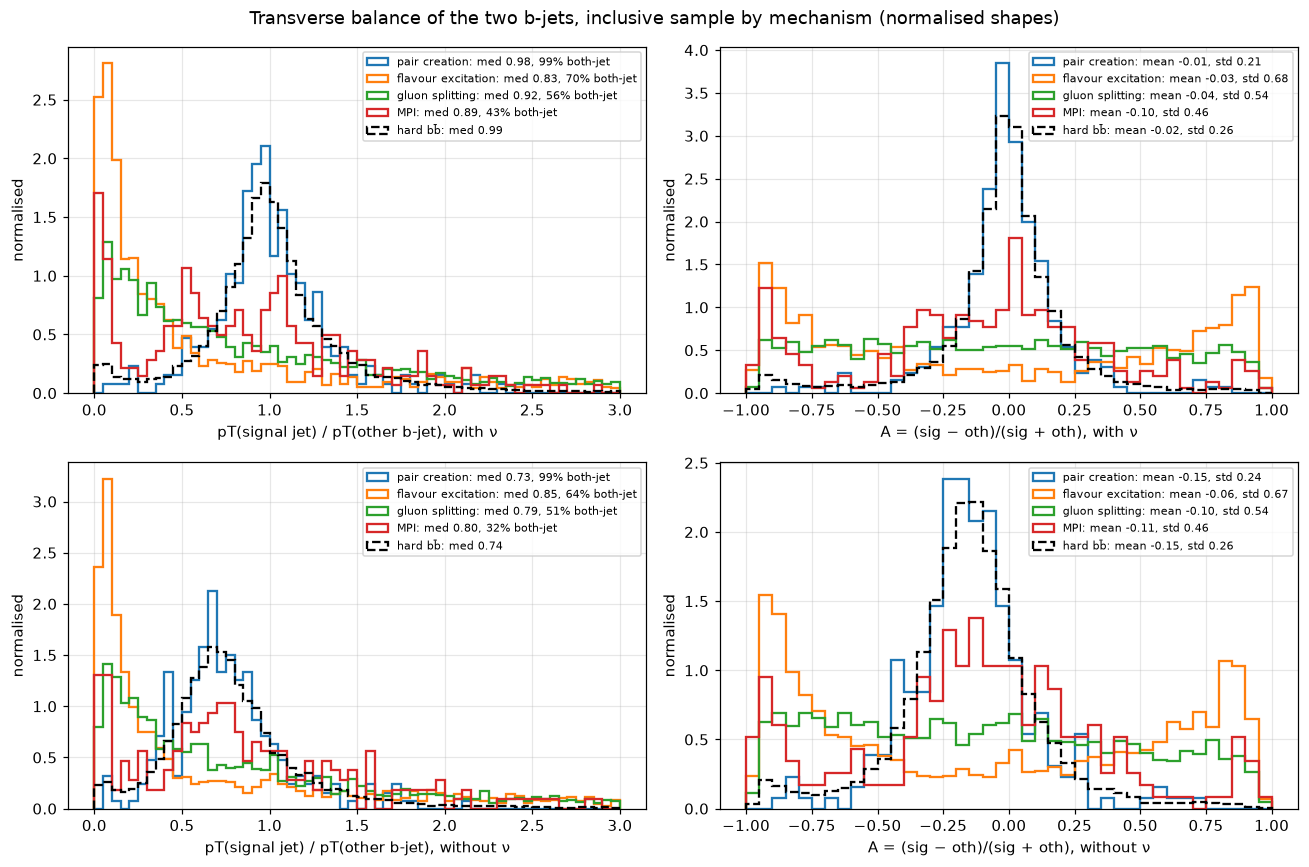

In [18]:
# Transverse balance of the two b-jets in the inclusive sample, by mechanism.
# Same definitions as above: events with both b-hadrons in (distinct) jets.
def balance(d, sig, oth):
    ok = d[f"{sig}_pt"].notna() & d[f"{oth}_pt"].notna() & (d.jets_shared == 0)
    r = (d[f"{sig}_pt"] / d[f"{oth}_pt"])[ok]
    A = ((d[f"{sig}_pt"] - d[f"{oth}_pt"]) / (d[f"{sig}_pt"] + d[f"{oth}_pt"]))[ok]
    return ok, r, A

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
rbins = np.linspace(0, 3, 61)
for row, (sig, oth, lab) in enumerate([("sigjet", "othjet", "with ν"), ("sigjetnonu", "othjetnonu", "without ν")]):
    for m in [1, 2, 3, 4]:
        s = di[di.mech == m]
        ok, r, A = balance(s, sig, oth)
        ax[row, 0].hist(r, bins=rbins, histtype="step", lw=1.5, color=cols[m], density=True,
                        label=f"{MECH[m]}: med {r.median():.2f}, {ok.mean():.0%} both-jet")
        ax[row, 1].hist(A, bins=np.linspace(-1, 1, 41), histtype="step", lw=1.5, color=cols[m], density=True,
                        label=f"{MECH[m]}: mean {A.mean():+.2f}, std {A.std():.2f}")
    ok, r, A = balance(df, sig, oth)
    ax[row, 0].hist(r, bins=rbins, histtype="step", lw=1.5, color="k", ls="--", density=True, label=f"hard bb̄: med {r.median():.2f}")
    ax[row, 1].hist(A, bins=np.linspace(-1, 1, 41), histtype="step", lw=1.5, color="k", ls="--", density=True, label=f"hard bb̄: mean {A.mean():+.2f}, std {A.std():.2f}")
    ax[row, 0].set_xlabel(f"pT(signal jet) / pT(other b-jet), {lab}")
    ax[row, 1].set_xlabel(f"A = (sig − oth)/(sig + oth), {lab}")
for a in ax.flat:
    a.set_ylabel("normalised"); a.legend(fontsize=7)
fig.suptitle("Transverse balance of the two b-jets, inclusive sample by mechanism (normalised shapes)")
fig.tight_layout()

ok, r, A = balance(di, "sigjet", "othjet")
okn, rn, An = balance(di, "sigjetnonu", "othjetnonu")
print(f"inclusive, all mechanisms: both b-hadrons in distinct jets {ok.mean():.1%} (hard sample {balance(df, 'sigjet', 'othjet')[0].mean():.1%})")
print(f"  ratio 16/50/84 %  with ν: {np.percentile(r, [16, 50, 84]).round(2)}   without ν: {np.percentile(rn, [16, 50, 84]).round(2)}")
print(f"  A mean/std        with ν: {A.mean():+.2f} / {A.std():.2f}   without ν: {An.mean():+.2f} / {An.std():.2f}")
for cut in [30, 50]:
    hard_like = di.B_pt > cut
    ok, r, A = balance(di[hard_like], "sigjet", "othjet")
    if len(r) == 0: continue
    print(f"inclusive with signal B pT > {cut} GeV ({hard_like.sum()} events): both-jet {ok.mean():.1%}, "
          f"ratio 16/50/84 % with ν {np.percentile(r, [16, 50, 84]).round(2)}, A mean {A.mean():+.2f} std {A.std():.2f}")

## Generator-level MET

`met` is the vector sum of all final-state neutrinos (CMS `genMetTrue`-like); `metsig` is the part from the signal B̄0 decay chain
(the τ neutrinos). With the b-jets back-to-back at ~100 GeV, the signal MET points along the signal jet.

/tmp/ipykernel_3408339/2553989412.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_pt"] = np.hypot(df[f"{p}_px"], df[f"{p}_py"])
/tmp/ipykernel_3408339/2553989412.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_phi"] = np.arctan2(df[f"{p}_py"], df[f"{p}_px"])


gen-MET median 27.9 GeV, mean 31.3 GeV; signal-chain part median 31.4 GeV
|MET_sig| / |MET| median 1.00;  MET > 50 GeV: 0.156;  MET > 100 GeV: 0.009


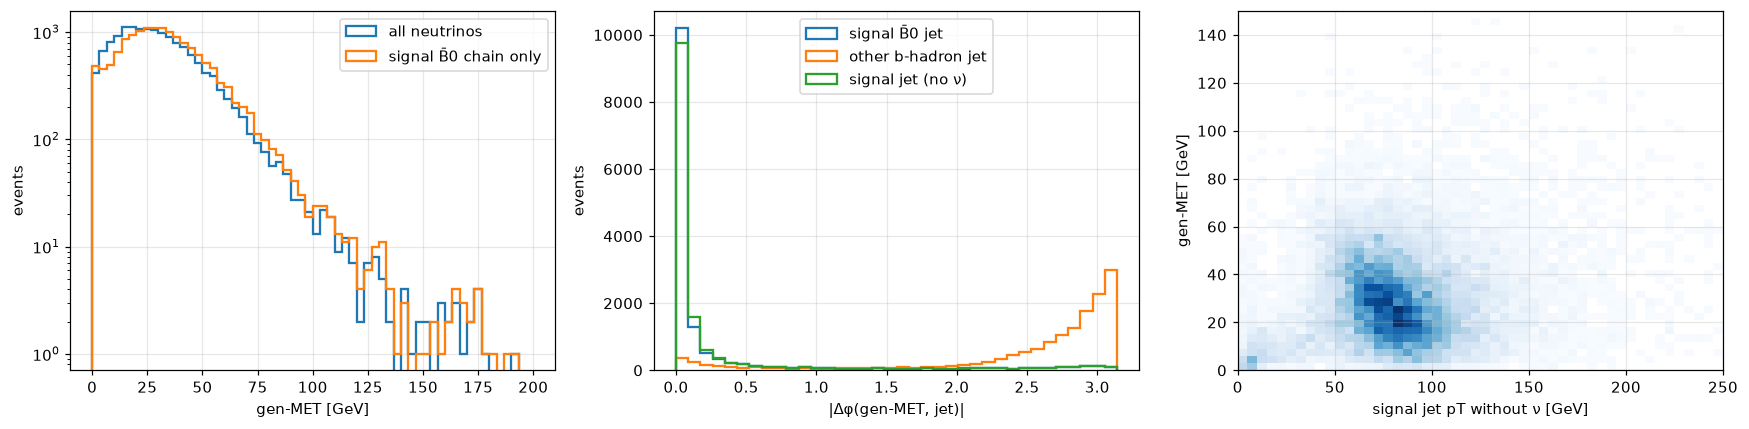

In [19]:
for p in ["met", "metsig"]:
    df[f"{p}_pt"] = np.hypot(df[f"{p}_px"], df[f"{p}_py"])
    df[f"{p}_phi"] = np.arctan2(df[f"{p}_py"], df[f"{p}_px"])

def dphi(a, b):
    return np.abs((df[f"{a}_phi"] - df[f"{b}_phi"] + np.pi) % (2 * np.pi) - np.pi)

frac_sig = df.metsig_pt / df.met_pt
print(f"gen-MET median {df.met_pt.median():.1f} GeV, mean {df.met_pt.mean():.1f} GeV; signal-chain part median {df.metsig_pt.median():.1f} GeV")
print(f"|MET_sig| / |MET| median {frac_sig.median():.2f};  MET > 50 GeV: {(df.met_pt > 50).mean():.3f};  MET > 100 GeV: {(df.met_pt > 100).mean():.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(df.met_pt,    bins=60, range=(0, 200), histtype="step", lw=1.5, label="all neutrinos")
ax[0].hist(df.metsig_pt, bins=60, range=(0, 200), histtype="step", lw=1.5, label="signal B̄0 chain only")
ax[0].set_xlabel("gen-MET [GeV]"); ax[0].set_ylabel("events"); ax[0].set_yscale("log"); ax[0].legend()

for tag, label in [("sigjet", "signal B̄0 jet"), ("othjet", "other b-hadron jet"), ("sigjetnonu", "signal jet (no ν)")]:
    ok = df[f"{tag}_px"].notna()
    ax[1].hist(dphi("met", tag)[ok], bins=36, range=(0, np.pi), histtype="step", lw=1.5, label=label)
ax[1].set_xlabel("|Δφ(gen-MET, jet)|"); ax[1].set_ylabel("events"); ax[1].legend(loc="upper center")

ok = df.sigjet_px.notna()
ax[2].hist2d(df.sigjetnonu_pt[ok], df.met_pt[ok], bins=[50, 50], range=[[0, 250], [0, 150]], cmap="Blues", cmin=1)
ax[2].set_xlabel("signal jet pT without ν [GeV]"); ax[2].set_ylabel("gen-MET [GeV]")
fig.tight_layout()

## q² of the τ pair

Flat phase space in Pythia (`meMode 0`), so this is just the kinematic envelope between (2 m_τ)² ≈ 12.6 GeV² and (m_B − m_K*)² ≈ 19.2 GeV².

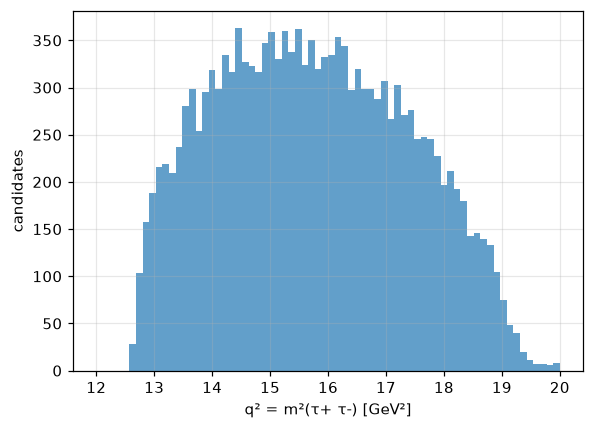

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(df.q2, bins=70, range=(12, 20), histtype="stepfilled", alpha=0.7)
ax.set_xlabel("q² = m²(τ+ τ-) [GeV²]")
ax.set_ylabel("candidates")
fig.tight_layout()